### Required Package Installation

In [2]:
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

import scanpy as sc

from scimilarity.cell_embedding import CellEmbedding
from scimilarity.utils import align_dataset, lognorm_counts

from analyses_utils import embedding_plots, loss_function_plot, measure_random_forest_performance, train_one_epoch
from pathlib import Path

import torch
import numpy as np

### Path Configuration

In [3]:
base_dir = Path.cwd()                                     # the folder where you run your notebook
# Input-files
model_path = base_dir / "model_v1.1"
data_path  = base_dir / "TCGA_mrna_tpm_unstranded.h5ad"

# Output-files
results_dir = base_dir / "embedding_results"
results_dir.mkdir(parents=True, exist_ok=True)
run_name = "SCimilarity"
out_file = results_dir / f"{run_name}.csv"

### Loading and Preprocessing Input Data

In [4]:
# Load SCimilarity model
ce = CellEmbedding(model_path = str(model_path))
# load TCGA data
TCGA = sc.read_h5ad(data_path)
TCGA = align_dataset(TCGA, ce.gene_order)
TCGA = lognorm_counts(TCGA)

label_encoder = LabelEncoder()
one_hot_encoder = OneHotEncoder(sparse_output = False)
y = label_encoder.fit_transform(TCGA.obs.cohort)
Y = one_hot_encoder.fit_transform(y[:, None])

### Pre-trained Embedding

In [5]:
embeddings = ce.get_embeddings(TCGA.X)
TCGA.obsm["X_scimilarity_pretrained"] = embeddings

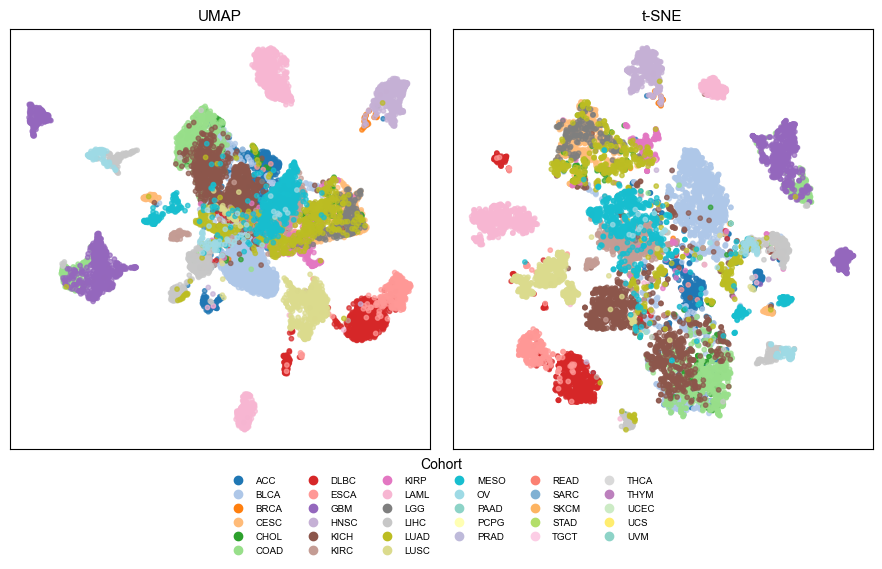

In [6]:
embedding_plots(
    data = TCGA.obsm["X_scimilarity_pretrained"], 
    classes = TCGA.obs["cohort"]
)

### Multiclass Classification

In [7]:
# Multiclass Classification of Embedding Results Using Random Forest Algorithm
# Measure the predictive performance using embeddings obtained from the trained model
measure_random_forest_performance(TCGA.obsm["X_scimilarity_pretrained"], TCGA.obs.cohort)

1.0
0.8508508508508509


In [9]:
np.savetxt(fname = str(out_file), 
           X = TCGA.obsm["X_scimilarity_pretrained"], delimiter = ",")